<a href="https://colab.research.google.com/github/nirmalprabhakarc/Machine-Learning-Alogarithms/blob/main/Implementation_of_Fuzzy_C_Means_Clustering_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nirmal
urk21cs2060

Aim:Develop the Fuzzy C-Means Clustering model to perform clustering, and to evaluate
the performance of the model.

Description:
- Fuzzy C-means (FCM) is an unsupervised learning algorithm that partitions a dataset into clusters based on similarity, without using labeled data.
- FCM is a soft clustering method where data points can belong to multiple clusters simultaneously, unlike hard clustering methods where each point belongs to only one cluster.
- The "C" in C-means indicates the number of clusters the algorithm aims to identify. FCM iteratively updates cluster centers to minimize an objective function, representing the centers of the clusters.
- FCM assigns each data point a degree of membership for each cluster, indicating the strength of its association with that cluster. This allows FCM to capture complex patterns where points may belong to multiple clusters with varying degrees of confidence.

Algorithm:
 - Import necessary python libraries
 - Read the data
 - Missing value imputation using mean (if any)
 - Standardize the data
 - Initialize fuzziness index (m) and number of iterations
 - Visualize the input features distribution using scatter plot
 - Perform the FCM clustering with different number of clusters
     - Decide optimal number of clusters between (2 to 5) using silhouette score (max)
 - Plot the curve against the number of clusters and the silhouette score
     - For the selected optimal number of clusters
       - Display the cluster centroids
       - Visualize the clusters using scatter plot with labels
       - Evaluate the performance of the clustering model using partition coefficient, partition entropy

In [ ]:
print("Q1:Import necessary python libraries")
print("URK21CS2060")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn import datasets

Q1:Import necessary python libraries
URK21CS3024


In [ ]:
print("Q2:Read the dataset")
print("URK21CS2060")

data = pd.read_csv('B5_wineFCM.csv')
data

Q2:Read the dataset
URK21CS3024


,Alcohol,Malic_Acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59
...,...,...
173,13.71,5.65
174,13.40,3.91
175,13.27,4.28
176,13.17,2.59


In [ ]:
print("Q3:Missing value imputation using mean (if required)")
print("URK21CS2060")

missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

# Impute missing values with the mean
data.fillna(data.mean(), inplace=True)


Q3:Missing value imputation using mean (if required)
URK21CS3024
Missing Values:
 Alcohol       0
Malic_Acid    0
dtype: int64


In [ ]:
print("Q4:Standardize the data using StandardScaler")
print("URK21CS2060")

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

Q4:Standardize the data using StandardScaler
URK21CS3024


In [ ]:
print("Q5:Initialize fuzziness index (m) and number of iterations")
print("URK21CS2060")

m = 2
max_iter = 100

Q5:Initialize fuzziness index (m) and number of iterations
URK21CS3024


Q6:Visualize the input features distribution using scatter plot
URK21CS3024


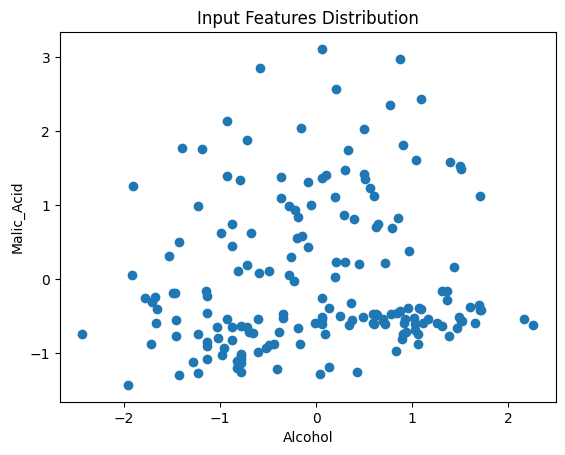

In [ ]:
print("Q6:Visualize the input features distribution using scatter plot")
print("URK21CS2060")

plt.scatter(data_scaled[:, 0], data_scaled[:, 1])
plt.xlabel('Alcohol')
plt.ylabel('Malic_Acid')
plt.title('Input Features Distribution')
plt.show()

In [ ]:
print("Q7:Perform the FCM clustering with different number of clusters and decide optimal number of clusters between (2 to 5) using silhouette score (max)")
print("URK21CS2060")

def fuzzy_c_means(data, n_clusters, m, max_iter):
    # Initialize cluster centers randomly
    centers = np.random.rand(n_clusters, data.shape[1])

    for _ in range(max_iter):
        # Calculate the fuzzy membership
        membership = calculate_membership(data, centers, m)

        # Update cluster centers
        new_centers = update_centers(data, membership, m)

        # Check for convergence
        if np.linalg.norm(new_centers - centers) < 1e-6:
            break

        centers = new_centers

    # Assign clusters based on maximum membership
    clusters = np.argmax(membership, axis=1)

    return clusters, centers

def calculate_membership(data, centers, m):
    # Calculate distance matrix
    distances = np.linalg.norm(data[:, np.newaxis] - centers, axis=2)

    # Calculate membership matrix
    membership = 1 / distances**(2/(m-1))
    membership = membership / np.sum(membership, axis=1)[:, np.newaxis]

    return membership

def update_centers(data, membership, m):
    numerator = np.sum((membership**m)[:, :, np.newaxis] * data[:, np.newaxis], axis=0)
    denominator = np.sum(membership**m, axis=0)[:, np.newaxis]

    centers = numerator / denominator

    return centers

# Calculate silhouette scores for different number of clusters
silhouette_scores = []
for n_clusters in range(2, 5):
    clusters, _ = fuzzy_c_means(data_scaled, n_clusters, m, max_iter)
    silhouette_scores.append(silhouette_score(data_scaled, clusters))

# Decide optimal number of clusters based on silhouette score
optimal_n_clusters = np.argmax(silhouette_scores) + 2
print(f'Optimal number of clusters: {optimal_n_clusters}')



Q7:Perform the FCM clustering with different number of clusters and decide optimal number of clusters between (2 to 5) using silhouette score (max)
URK21CS3024
Optimal number of clusters: 3


Q8:Plot the curve against the number of clusters and the silhouette score
URK21CS3024


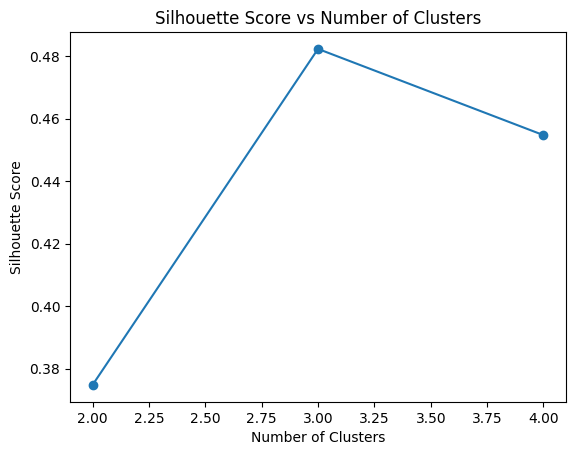

In [ ]:
print("Q8:Plot the curve against the number of clusters and the silhouette score")
print("URK21CS2060")

plt.plot(range(2, 5), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

Q9. For the selected optimal number of clusters, display the cluster centroids and visualize the clusters using scatter plot with labels
URK21CS3024
Cluster Centroids:
Cluster 1: [0.10589014 1.37957565]
Cluster 2: [ 0.94034667 -0.46607306]
Cluster 3: [-0.96716511 -0.63547143]


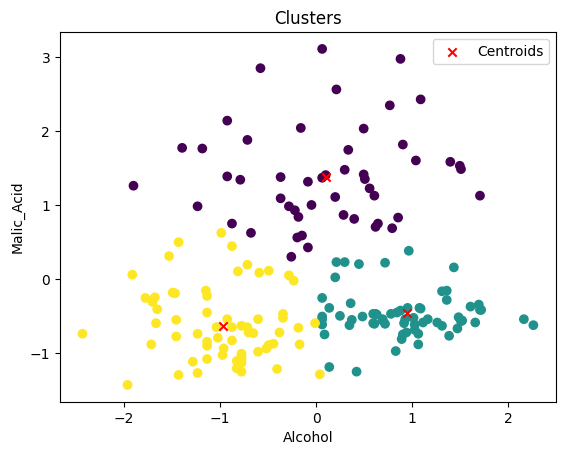

In [ ]:
print("Q9. For the selected optimal number of clusters, display the cluster centroids and visualize the clusters using scatter plot with labels")
print("URK21CS2060")

optimal_clusters, optimal_centers = fuzzy_c_means(data_scaled, optimal_n_clusters, m, max_iter)

# Display cluster centroids
print(f'Cluster Centroids:')
for i, centroid in enumerate(optimal_centers):
    print(f'Cluster {i+1}: {centroid}')

# Visualize the clusters using scatter plot with labels
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=optimal_clusters, cmap='viridis')
plt.scatter(optimal_centers[:, 0], optimal_centers[:, 1], marker='x', color='red', label='Centroids')
plt.xlabel('Alcohol')
plt.ylabel('Malic_Acid')
plt.title('Clusters')
plt.legend()
plt.show()


In [ ]:
print("Q10. Evaluate the performance of the clustering model using partition coefficient, partition entropy")
print("URK21CS2060")

def partition_coefficient(data, clusters):
    n = len(data)
    k = len(np.unique(clusters))

    pc = 0
    for i in range(k):
        n_i = np.sum(clusters == i)
        pc += n_i*(n_i-1)/(n*(n-1))

    return pc

def partition_entropy(data, clusters):
    n = len(data)
    k = len(np.unique(clusters))

    pe = 0
    for i in range(k):
        n_i = np.sum(clusters == i)
        if n_i > 0:
            pe -= (n_i / n) * np.log(n_i / n)

    return pe

# Evaluate performance
pc = partition_coefficient(data_scaled, optimal_clusters)
pe = partition_entropy(data_scaled, optimal_clusters)
print(f'Partition Coefficient: {pc}')
print(f'Partition Entropy: {pe}')


Q10. Evaluate the performance of the clustering model using partition coefficient, partition entropy
URK21CS3024
Partition Coefficient: 0.3337142131657462
Partition Entropy: 1.0922431854525048


Result:The program for fuzzy c-means clustering compiled and executed successfully